In [164]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv('USA Housing Dataset.csv')
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-09 00:00:00,376000.0,3.0,2.00,1340,1384,3.0,0,0,3,1340,0,2008,0,9245-9249 Fremont Ave N,Seattle,WA 98103,USA
1,2014-05-09 00:00:00,800000.0,4.0,3.25,3540,159430,2.0,0,0,3,3540,0,2007,0,33001 NE 24th St,Carnation,WA 98014,USA
2,2014-05-09 00:00:00,2238888.0,5.0,6.50,7270,130017,2.0,0,0,3,6420,850,2010,0,7070 270th Pl SE,Issaquah,WA 98029,USA
3,2014-05-09 00:00:00,324000.0,3.0,2.25,998,904,2.0,0,0,3,798,200,2007,0,820 NW 95th St,Seattle,WA 98117,USA
4,2014-05-10 00:00:00,549900.0,5.0,2.75,3060,7015,1.0,0,0,5,1600,1460,1979,0,10834 31st Ave SW,Seattle,WA 98146,USA


https://www.kaggle.com/datasets/fratzcan/usa-house-prices?resource=download

In [165]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Drop useless text/constant columns
cols_to_drop = ['street', 'state', 'country', 'date']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 2. Feature Engineering: House Age
# It's easier for the model to understand "Age" than "Year Built"
df['age'] = 2014 - df['yr_built']  # Using 2014 since that's your data's year
df['was_renovated'] = df['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)

df[(df['price'] > 0) & (df['price'] < 1_000_000)]

# 3. Target Encoding for City and Zipcode
# We calculate the average log_price per city/zip to capture "location value"
df['target_y'] = np.log1p(df['price'])

for col in ['city', 'statezip']:
    # Map the average price of that location to the row
    location_map = df.groupby(col)['target_y'].mean()
    df[f'{col}_encoded'] = df[col].map(location_map)

# 4. Final Cleanup
# Drop the original text columns and the raw price
X = df.drop(['price', 'target_y', 'city', 'statezip', 'yr_built', 'yr_renovated'], axis=1)
y = df['target_y']

# 5. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,age,was_renovated,city_encoded,statezip_encoded
0,3.0,2.00,1340,1384,3.0,0,0,3,1340,0,6,0,13.021176,13.235472
1,4.0,3.25,3540,159430,2.0,0,0,3,3540,0,7,0,12.977815,12.977815
2,5.0,6.50,7270,130017,2.0,0,0,3,6420,850,4,0,13.166423,13.281333
3,3.0,2.25,998,904,2.0,0,0,3,798,200,7,0,13.021176,13.186374
4,5.0,2.75,3060,7015,1.0,0,0,5,1600,1460,35,0,13.021176,12.445510


In [166]:
y.describe()

count    4140.000000
mean       12.909894
std         1.514313
min         0.000000
25%        12.676079
50%        13.038984
75%        13.398670
max        17.096046
Name: target_y, dtype: float64

In [167]:
print(X.info()) # Check for non-numeric columns
print(X.isnull().sum()) # Check for missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4140 entries, 0 to 4139
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bedrooms          4140 non-null   float64
 1   bathrooms         4140 non-null   float64
 2   sqft_living       4140 non-null   int64  
 3   sqft_lot          4140 non-null   int64  
 4   floors            4140 non-null   float64
 5   waterfront        4140 non-null   int64  
 6   view              4140 non-null   int64  
 7   condition         4140 non-null   int64  
 8   sqft_above        4140 non-null   int64  
 9   sqft_basement     4140 non-null   int64  
 10  age               4140 non-null   int64  
 11  was_renovated     4140 non-null   int64  
 12  city_encoded      4140 non-null   float64
 13  statezip_encoded  4140 non-null   float64
dtypes: float64(5), int64(9)
memory usage: 452.9 KB
None
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot          

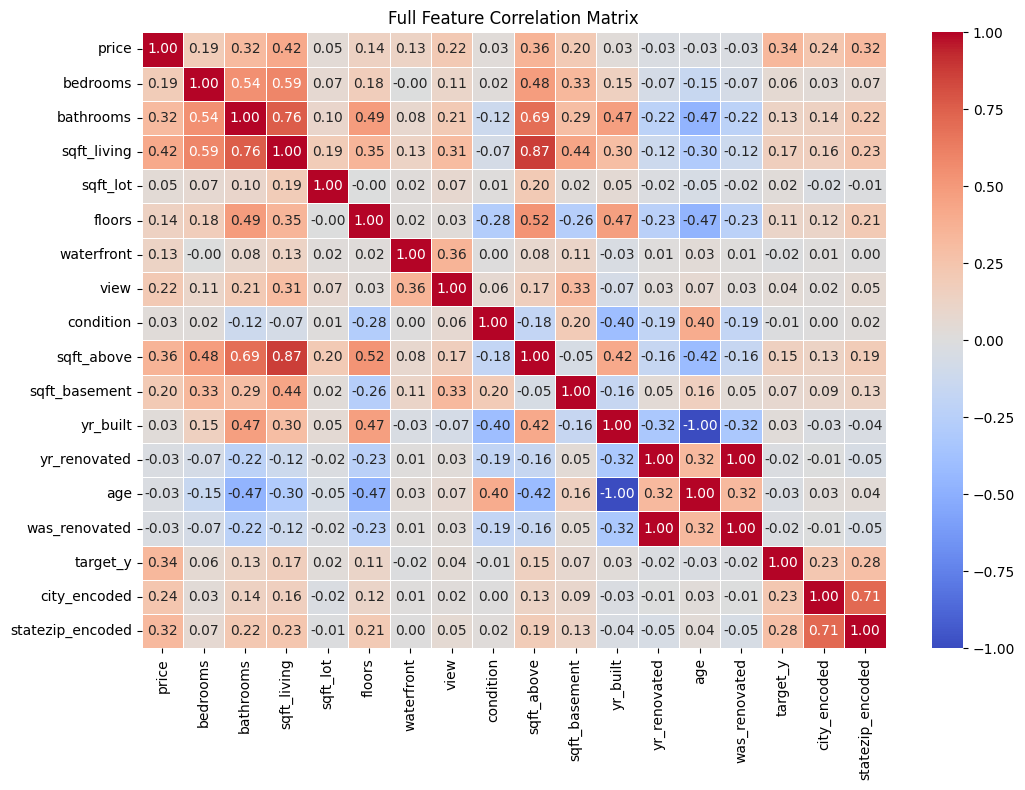

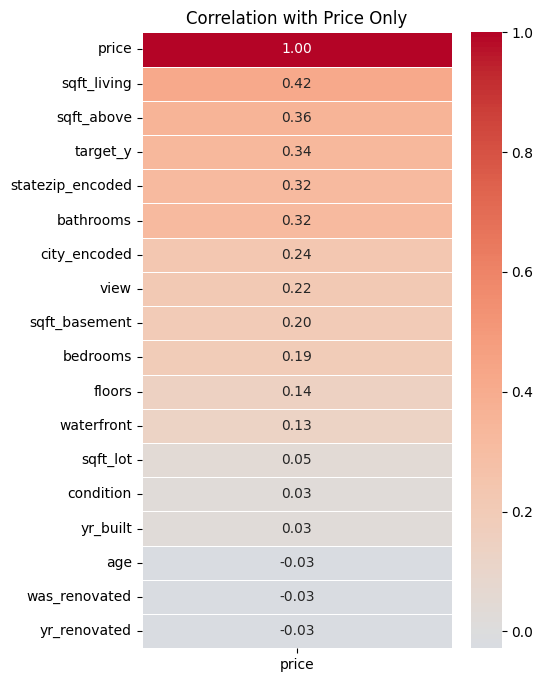

In [168]:
# Correlation heatmaps
import matplotlib.pyplot as plt
import seaborn as sns

full_corr = df.corr(numeric_only=True)
price_corr = full_corr[['price']].sort_values(by='price', ascending=False)

# Full correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(full_corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Full Feature Correlation Matrix")
plt.show()

# Correlation with price only
plt.figure(figsize=(5, 8)) 
sns.heatmap(price_corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Correlation with Price Only")
plt.show()

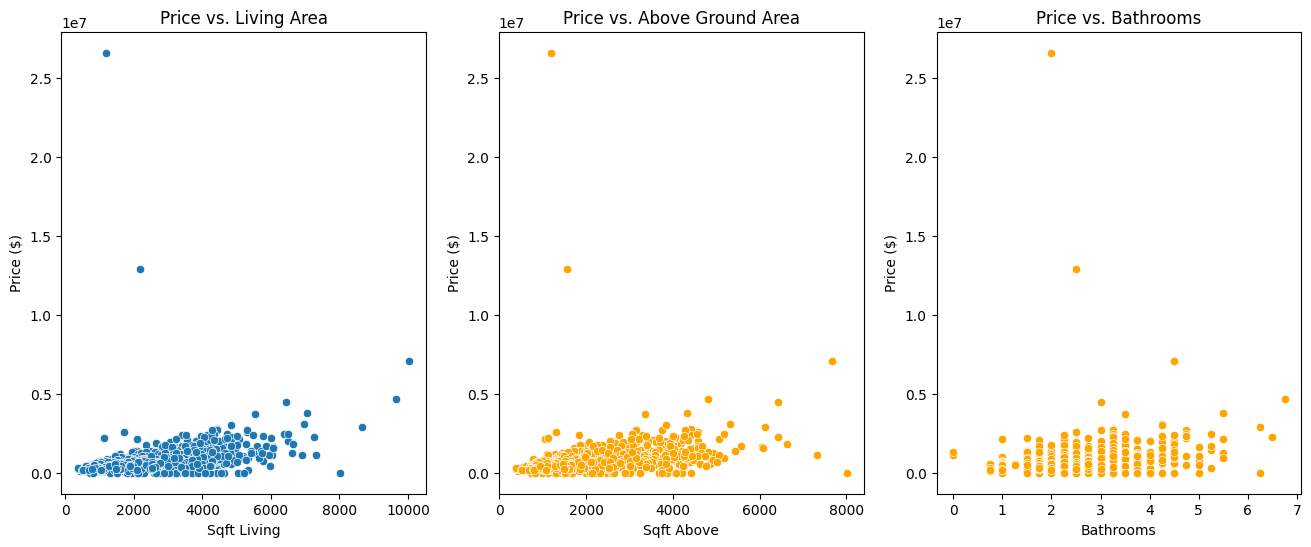

In [169]:
# Scatter plots for top correlated features
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# sft_living
sns.scatterplot(data=df, x='sqft_living', y='price', ax=axes[0])
axes[0].set_title('Price vs. Living Area')
axes[0].set_xlabel('Sqft Living')
axes[0].set_ylabel('Price ($)')

# sqft_above
sns.scatterplot(data=df, x='sqft_above', y='price', ax=axes[1], color='orange')
axes[1].set_title('Price vs. Above Ground Area')
axes[1].set_xlabel('Sqft Above')
axes[1].set_ylabel('Price ($)')

# bathrooms
sns.scatterplot(data=df, x='bathrooms', y='price', ax=axes[2], color='orange')
axes[2].set_title('Price vs. Bathrooms')
axes[2].set_xlabel('Bathrooms')
axes[2].set_ylabel('Price ($)')

plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import make_pipeline

# 1. QUANTILE-BASED FILTERING
# We remove the bottom 1% and top 1% of prices to handle the outliers
lower_limit = df['price'].quantile(0.01)
upper_limit = df['price'].quantile(0.99)

# Also ensure we filter out the 0s
df_clean = df[(df['price'] >= lower_limit) & (df['price'] <= upper_limit) & (df['price'] > 0)].copy()

print(f"Filtering Range: ${lower_limit:,.2f} to ${upper_limit:,.2f}")

# 2. FEATURE SELECTION
features = ['sqft_living', 'bedrooms', 'bathrooms', 'age', 'waterfront', 'view', 'condition']
X = df_clean[features]
if 'city_encoded' in df_clean.columns:
    X = pd.concat([X, df_clean[['city_encoded']]], axis=1)

y = np.log1p(df_clean['price'])

# 3. SPLIT & MODEL
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = make_pipeline(StandardScaler(), LinearRegression())
lr_model.fit(X_train, y_train)

# 4. EVALUATE
log_preds = lr_model.predict(X_test)
real_preds = np.expm1(log_preds)
real_actual = np.expm1(y_test)

print(f"New R^2: {r2_score(y_test, log_preds):.4f}")
print(f"New MAE: ${mean_absolute_error(real_actual, real_preds):,.2f}")

# 5. SEE THE COEFFICIENTS (How to access from pipeline)
regressor = lr_model.named_steps['linearregression']
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': regressor.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\n--- Feature Impact ---")
print(importance_df)

Filtering Range: $0.00 to $2,018,420.00
New R^2: 0.6650
New MAE: $117,183.94

--- Feature Impact ---
        Feature  Coefficient
0   sqft_living     0.268200
7  city_encoded     0.203782
2     bathrooms     0.092384
3           age     0.066897
5          view     0.052497
6     condition     0.026251
4    waterfront     0.015230
1      bedrooms    -0.035809


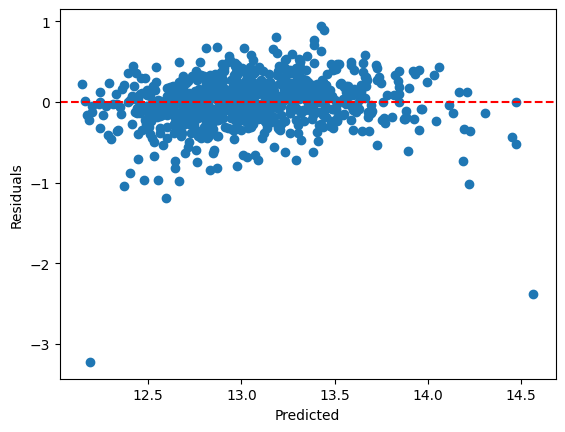

In [171]:
import matplotlib.pyplot as plt
residuals = y_test - log_preds
plt.scatter(log_preds, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

In [172]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# 1. Initialize the Model
# n_estimators = number of trees. 100 is the industry standard starting point.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train (Fit) the model
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

# 5. Check the R^2 Score
print(f"Random Forest R^2: {r2_score(y_test, rf_predictions):.4f}")
print(f"Random Forest MAE: ${mean_absolute_error(y_test, rf_predictions):,.2f}")

Random Forest R^2: 0.7117
Random Forest MAE: $0.20


In [173]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Initialize with Early Stopping INSIDE the model call
xgb_model = xgb.XGBRegressor(
    n_estimators=2000, 
    learning_rate=0.05, 
    max_depth=6, 
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,  # Moved to here!
    n_jobs=-1,
    random_state=42
)

# 2. Fit the model 
# We still need the eval_set so the model has something to "check" against
xgb_model.fit(
    X_train, np.log1p(y_train),
    eval_set=[(X_test, np.log1p(y_test))],
    verbose=False
)

# 3. Predict & Evaluate
log_preds = xgb_model.predict(X_test)
final_predictions = np.expm1(log_preds)

print(f"XGBoost R^2 Score: {r2_score(y_test, final_predictions):.4f}")
print(f"XGBoost MAE: ${mean_absolute_error(y_test, final_predictions):,.2f}")

XGBoost R^2 Score: 0.7379
XGBoost MAE: $0.19


In [174]:
import tensorflow as tf
from tensorflow.keras import layers 
from sklearn.metrics import r2_score, mean_absolute_error

# rely on sklearn / numpy imports from earlier cells (do not re-import)

# 1. Preprocessing (Combined Log & Split)
y_train_log, y_test_log = np.log1p(y_train), np.log1p(y_test)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. Modern Model Definition (Condensed)
ffn_model = tf.keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1) 
])

# 3. Compile & Fit (Inline callbacks and optimizer)
ffn_model.compile(optimizer=tf.keras.optimizers.Adam(0.005), loss="mse")

ffn_model.fit(
    X_train, y_train_log, 
    epochs=150, 
    batch_size=16,
    validation_split=0.1, 
    verbose=True,   
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
)



Epoch 1/150


C:\Users\DEVal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2713 - val_loss: 0.0705
Epoch 2/150
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0466 - val_loss: 0.0155
Epoch 3/150
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0305 - val_loss: 0.0198
Epoch 4/150
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0230 - val_loss: 0.0280
Epoch 5/150
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0222 - val_loss: 0.0212
Epoch 6/150
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0180 - val_loss: 0.0258
Epoch 7/150
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0142 - val_loss: 0.0288
Epoch 8/150
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0112 - val_loss: 0.0173
Epoch 9/150
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0112 - val_loss: 0.0105
Epoch 10/150
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0082 - val_loss: 0.0110
Epoch 11/150
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0072 - val_loss: 0.0079
Epoch 12/150
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [175]:
# 4. Evaluation (The "One-Liner" approach)
preds = np.expm1(model.predict(X_test))
y_true = np.expm1(y_test_log)

print(f"FFN R2: {r2_score(y_true, preds):.4f} \nFFN MAE: ${mean_absolute_error(y_true, preds):,.2f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
FFN R2: 0.6662 
FFN MAE: $0.22
